In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier # untuk perbandingan

from model.network import NeuralNetwork
from model.layers import DenseLayer
from model.activation import ActivationLayer

In [2]:
# load dataset
data = pd.read_csv('data/datasetml_2026.csv')

## 1. Exploratory Data Analysis (EDA)

### 1.1 Informasi Umum Data

In [3]:
data.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB


In [5]:
data.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [6]:
# Cek missing values
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [7]:
# Distribusi kelas target
print(data['placement_status'].value_counts())
print(data['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


### 1.2 Visualisasi Data

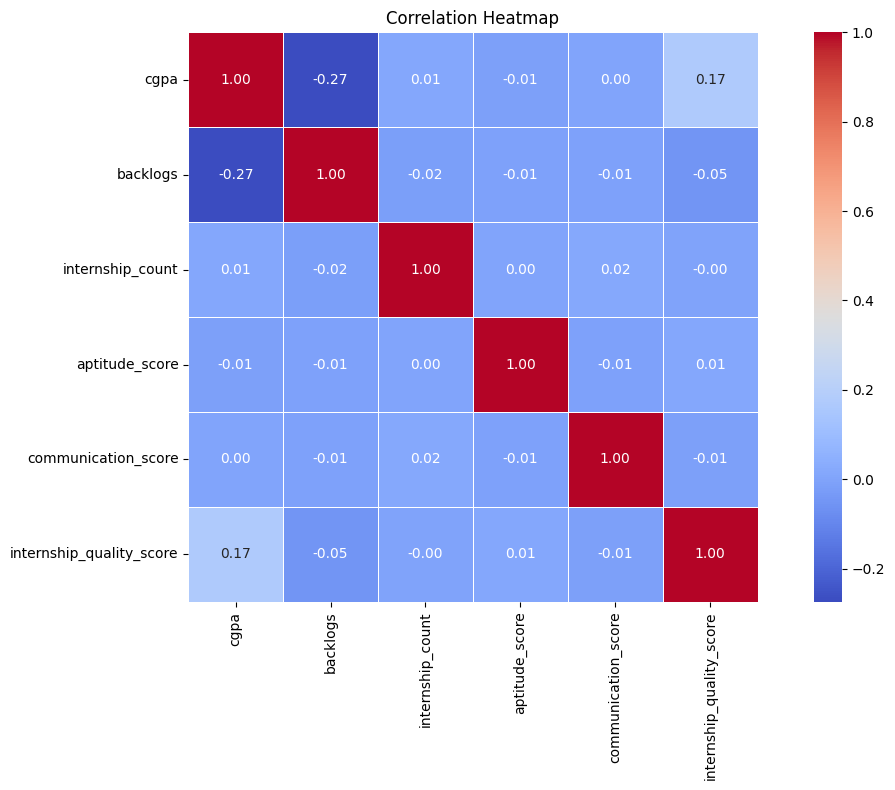

In [8]:
# Snippet: heatmap korelasi fitur numerik
# -------------------------------------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()


plt.figure(figsize=(12, 8))
corr_matrix = data[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

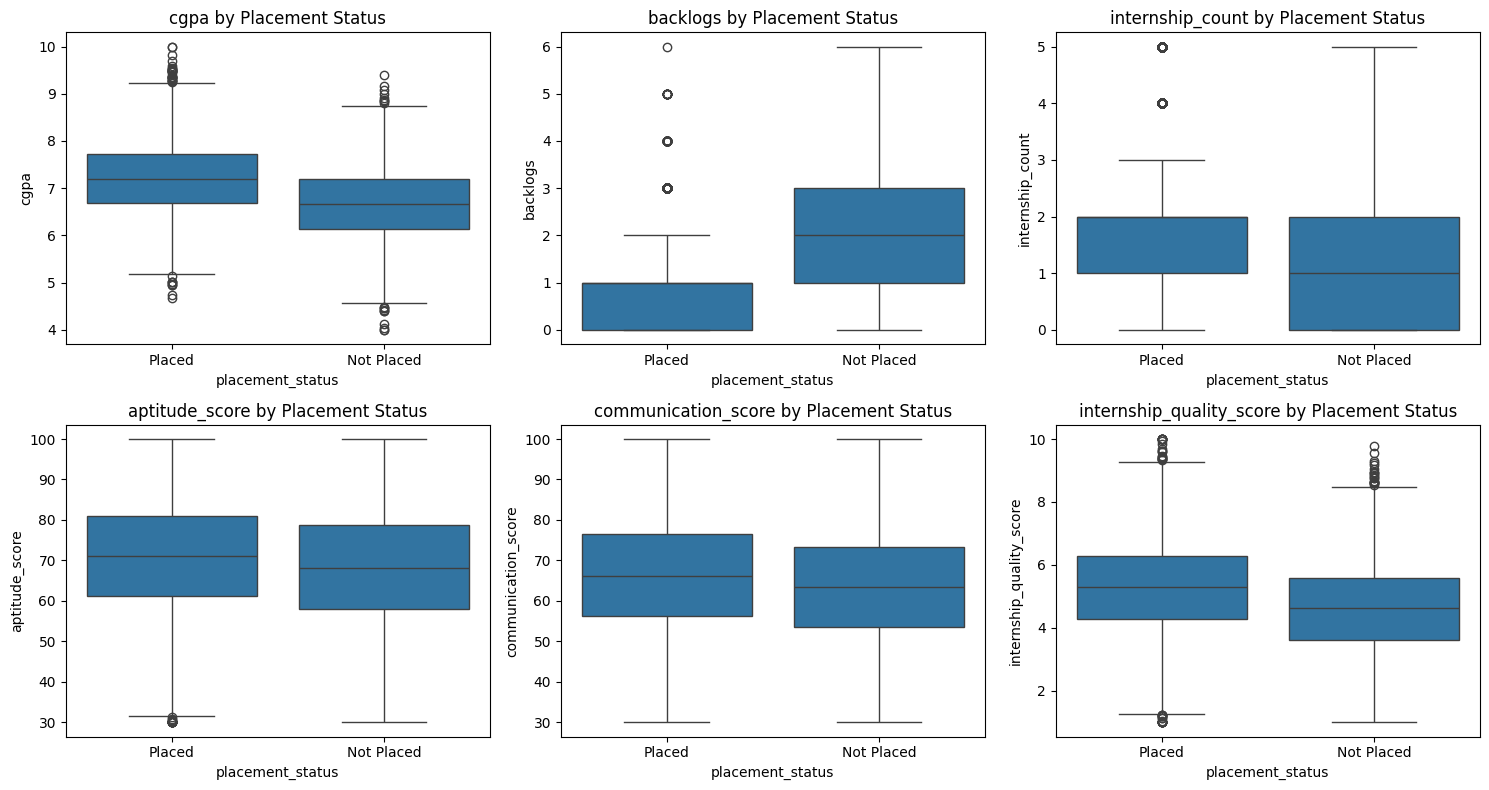

In [9]:
# Snippet: boxplot untuk deteksi outlier per kelas target
# -------------------------------------------------------
num_features = [col for col in num_cols if col != 'placement_status']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_features):
    sns.boxplot(data=data, x='placement_status', y=col, ax=ax)
    ax.set_title(f'{col} by Placement Status')

plt.tight_layout()
plt.show()

### 2. Data Cleaning dan Preprocessing

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# copy data
data_copy = data.copy()

TARGET_COL = 'placement_status'
CAT_COLS = ['college_tier', 'country', 'university_ranking_band',
            'specialization', 'industry']
NUM_COLS = [c for c in data_copy.columns if c not in CAT_COLS + [TARGET_COL]]

print("Categorical Columns:", CAT_COLS)
print("Numerical Columns:", NUM_COLS)

Categorical Columns: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
Numerical Columns: ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


In [11]:
# pisah feature dan target
X = data_copy.drop(columns=[TARGET_COL]).copy()
y = data_copy[TARGET_COL].map({'Not Placed': 0, 'Placed': 1}).astype(int)

# split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Train target distribution:")
print(y_train.value_counts(normalize=True))
print("Validation target distribution:")
print(y_val.value_counts(normalize=True))

Train shape: (8000, 11)
Validation shape: (2000, 11)
Train target distribution:
placement_status
1    0.61525
0    0.38475
Name: proportion, dtype: float64
Validation target distribution:
placement_status
1    0.6155
0    0.3845
Name: proportion, dtype: float64


In [12]:
# handle missing values
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[NUM_COLS] = num_imputer.fit_transform(X_train[NUM_COLS])
X_val[NUM_COLS] = num_imputer.transform(X_val[NUM_COLS])

X_train[CAT_COLS] = cat_imputer.fit_transform(X_train[CAT_COLS])
X_val[CAT_COLS] = cat_imputer.transform(X_val[CAT_COLS])

In [13]:
# handle outlier
def get_iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

iqr_bounds = {}

print("Outliers in TRAIN before clipping:")
for col in NUM_COLS:
    lower, upper = get_iqr_bounds(X_train[col])
    iqr_bounds[col] = (lower, upper)

    n_train_outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    n_val_outliers = ((X_val[col] < lower) | (X_val[col] > upper)).sum()

    print(f"{col}: train={n_train_outliers}, val={n_val_outliers}")

    X_train[col] = X_train[col].clip(lower, upper)
    X_val[col] = X_val[col].clip(lower, upper)


Outliers in TRAIN before clipping:
cgpa: train=59, val=24
backlogs: train=23, val=6
internship_count: train=518, val=144
aptitude_score: train=0, val=0
communication_score: train=0, val=0
internship_quality_score: train=31, val=5


In [14]:
# scaling numerik
scaler = StandardScaler()

X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[NUM_COLS]),
    columns=NUM_COLS,
    index=X_train.index
)

X_val_num = pd.DataFrame(
    scaler.transform(X_val[NUM_COLS]),
    columns=NUM_COLS,
    index=X_val.index
)

In [15]:
# encoding kategorikal
encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train[CAT_COLS]),
    columns=encoder.get_feature_names_out(CAT_COLS),
    index=X_train.index
)

X_val_cat = pd.DataFrame(
    encoder.transform(X_val[CAT_COLS]),
    columns=encoder.get_feature_names_out(CAT_COLS),
    index=X_val.index
)

In [16]:
# concat data
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_val = pd.concat([X_val_num, X_val_cat], axis=1)

y_train = y_train.loc[X_train.index]
y_val = y_val.loc[X_val.index]

print("Final X_train shape:", X_train.shape)
print("Final X_val shape:", X_val.shape)
print("Final y_train shape:", y_train.shape)
print("Final y_val shape:", y_val.shape)

print("\nSample X_train:")
print(X_train.head())

print("\nSample y_train:")
print(y_train.head())

Final X_train shape: (8000, 23)
Final X_val shape: (2000, 23)
Final y_train shape: (8000,)
Final y_val shape: (2000,)

Sample X_train:
          cgpa  backlogs  internship_count  aptitude_score  \
2014  0.835800 -0.212922         -1.326856        1.354853   
3522 -0.973037 -0.212922          0.514401        1.161440   
83   -0.522229 -1.089597         -0.406227       -0.879371   
9038  0.779925 -1.089597          0.514401       -1.064178   
3984  0.244731  2.417102         -1.326856       -1.007427   

      communication_score  internship_quality_score  college_tier_Tier 2  \
2014             0.663750                  0.917340                  0.0   
3522            -1.195912                 -1.074895                  0.0   
83               1.936316                  1.399386                  1.0   
9038            -1.299611                  1.262876                  1.0   
3984            -0.271013                  0.002309                  1.0   

      college_tier_Tier 3  country_

In [17]:
X_train_np = X_train.to_numpy(dtype=np.float32)
X_val_np = X_val.to_numpy(dtype=np.float32)

y_train_np = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
y_val_np = y_val.to_numpy(dtype=np.float32).reshape(-1, 1)

print(X_train_np.shape, X_val_np.shape)
print(y_train_np.shape, y_val_np.shape)

(8000, 23) (2000, 23)
(8000, 1) (2000, 1)


### 3. Modeling and Validation

In [18]:
# Helper: evaluasi model dan simpan hasil
from sklearn.metrics import f1_score


results = {}

def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred = model.predict(X_val)
    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_val, y_pred,
                                target_names=['Rejected (0)', 'Approved (1)']))
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
    return macro_f1

In [19]:
#  init import class 

from model.functions import ActivationFunctions, LossFunctions
from model.initializers import Initializers

activation_fn = ActivationFunctions()
loss_fn = LossFunctions()
init_fn = Initializers()

relu = activation_fn.relu
relu_prime = activation_fn.relu_prime
sigmoid = activation_fn.sigmoid
sigmoid_prime = activation_fn.sigmoid_prime
linear = activation_fn.linear
linear_prime = activation_fn.linear_prime
softmax = activation_fn.softmax
softmax_prime = activation_fn.softmax_prime
hyperbolic_tangent = activation_fn.hyperbolic_tangent
hyperbolic_tangent_prime = activation_fn.hyperbolic_tangent_prime

mse = loss_fn.mse
mse_prime = loss_fn.mse_prime
bce = loss_fn.binary_cross_entropy
bce_prime = loss_fn.bce_prime
cce = loss_fn.categorical_cross_entropy
cce_prime = loss_fn.cce_prime
leaky_relu = activation_fn.leaky_relu
leaky_relu_prime = activation_fn.leaky_relu_prime
elu = activation_fn.elu
elu_prime = activation_fn.elu_prime
swish = activation_fn.swish
swish_prime = activation_fn.swish_prime

normal_init = init_fn.normal_init
uniform_init = init_fn.uniform_init
he_init = init_fn.he_init
uniform_init = init_fn.uniform_init
xavier_init = init_fn.xavier_init

Memulai 5-Fold Cross Validation...

Fold 1 Accuracy: 0.7312
Fold 2 Accuracy: 0.7562
Fold 3 Accuracy: 0.7312
Fold 4 Accuracy: 0.7488
Fold 5 Accuracy: 0.7350
------------------------------
Rata-rata Akurasi (5-Fold): 0.7405
Standar Deviasi: 0.0102


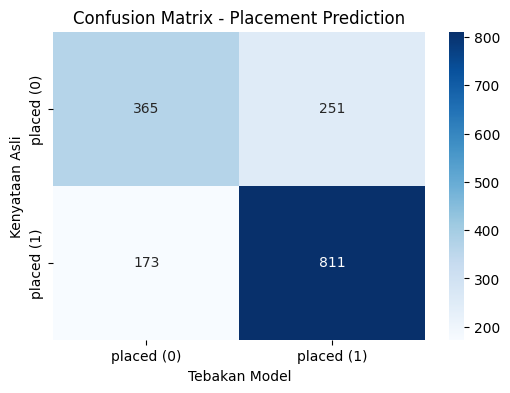

In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

k = 5 # Jumlah fold
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []

print(f"Memulai {k}-Fold Cross Validation...\n")


for i, (train_index, test_index) in enumerate(skf.split(X_train_np, y_train_np)):
    
    # Bagi data berdasarkan indeks dari sklearn
    X_train_fold, X_val_fold = X_train_np[train_index], X_train_np[test_index]
    y_train_fold, y_val_fold = y_train_np[train_index], y_train_np[test_index]
    
    input_size = X_train_fold.shape[1]
    
    model_fold = NeuralNetwork()
    model_fold.add(DenseLayer(input_size, 10, initializer_func=normal_init, mean=0, variance=0.1))  
    model_fold.add(ActivationLayer(hyperbolic_tangent, hyperbolic_tangent_prime))
    model_fold.add(DenseLayer(10, 1, initializer_func=normal_init, mean=0, variance=0.1))
    model_fold.add(ActivationLayer(sigmoid, sigmoid_prime))
    
    model_fold.use(mse, mse_prime)

    model_fold.train(X_train_fold, y_train_fold, epochs=500, learning_rate=0.1, verbose=False)
    
    y_pred_fold = model_fold.predict(X_val_fold)
    
    y_pred_flattened = np.array(y_pred_fold).flatten()
    
    # Ubah ke biner (0 atau 1)
    y_pred_binary = (y_pred_flattened >= 0.5).astype(int)
    
    # Hitung akurasi
    acc = accuracy_score(y_val_fold, y_pred_binary)
    fold_accuracies.append(acc)
    
    print(f"Fold {i+1} Accuracy: {acc:.4f}")


print("-" * 30)
print(f"Rata-rata Akurasi ({k}-Fold): {np.mean(fold_accuracies):.4f}")
print(f"Standar Deviasi: {np.std(fold_accuracies):.4f}")

cm = confusion_matrix(y_val_fold, y_pred_binary)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['placed (0)', 'placed (1)'], 
            yticklabels=['placed (0)', 'placed (1)'])
plt.xlabel('Tebakan Model')
plt.ylabel('Kenyataan Asli')
plt.title('Confusion Matrix - Placement Prediction')
plt.show()

## Pengujian

### Pengujian 1. Hyperparameter

### Pengujian 1.1. Pengaruh Width dan Depth

#### Width berbeda


Training model dengan Width: 16

Training model dengan Width: 64

Training model dengan Width: 128


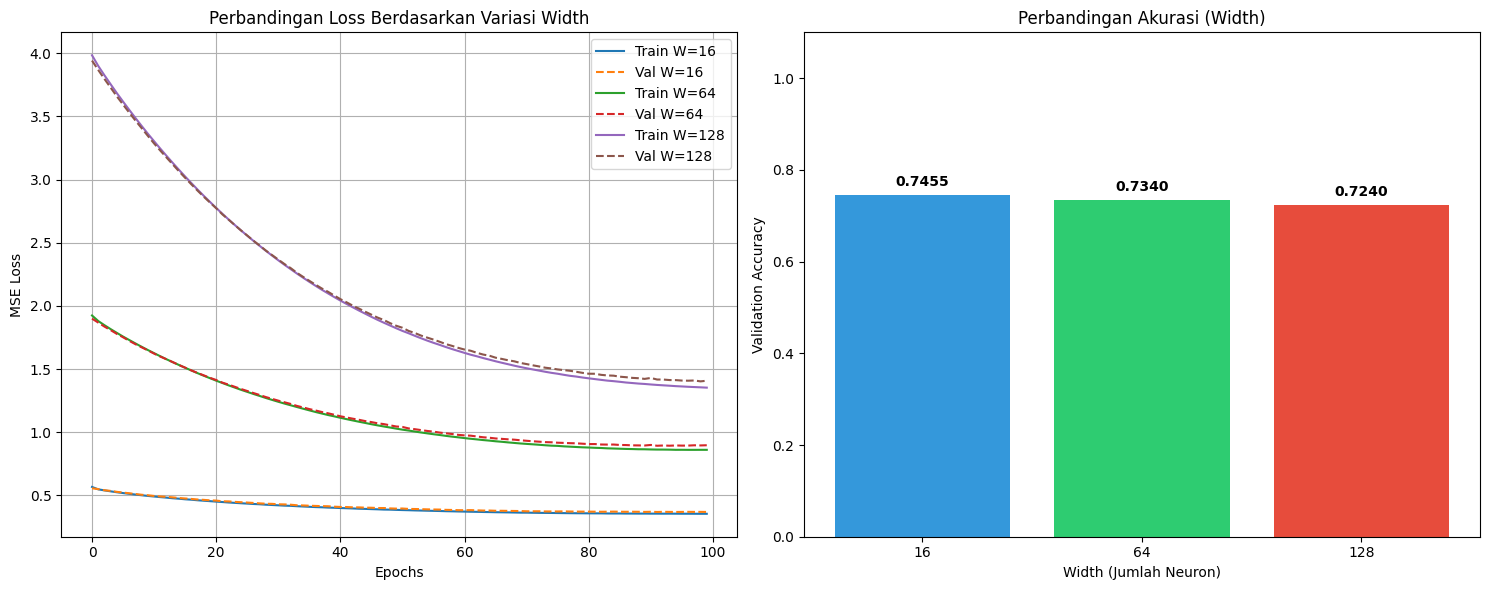

In [21]:
import matplotlib.pyplot as plt

widths = [16, 64, 128] # Kecil, Menengah, Besar
results = {}
val_accuracies = []
input_dim = X_train_np.shape[1]

for w in widths:
    print(f"\nTraining model dengan Width: {w}")
    
    model = NeuralNetwork()
    
    model.add(DenseLayer(input_dim, w, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    
    model.add(DenseLayer(w, w, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    
    model.add(DenseLayer(w, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))

    model.use(mse, mse_prime)

    results[w] = model.train(
        X_train_np, y_train_np,
        X_val_np, y_val_np,
        epochs=100,
        batch_size=32,
        learning_rate=0.1,
        verbose=0
    )

    y_pred = model.predict(X_val_np)
    y_pred_binary = (np.array(y_pred).flatten() >= 0.5).astype(int)
    acc = accuracy_score(y_val_np, y_pred_binary)
    val_accuracies.append(acc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for w in widths:
    ax1.plot(results[w]['train_loss'], label=f'Train W={w}')
    ax1.plot(results[w]['val_loss'], '--', label=f'Val W={w}')
ax1.set_title('Perbandingan Loss Berdasarkan Variasi Width')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE Loss')
ax1.legend()
ax1.grid(True)

bars = ax2.bar([str(w) for w in widths], val_accuracies, color=['#3498db', '#2ecc71', '#e74c3c'])
ax2.set_title('Perbandingan Akurasi (Width)')
ax2.set_xlabel('Width (Jumlah Neuron)')
ax2.set_ylabel('Validation Accuracy')
ax2.set_ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Depth Berbeda


Training model dengan Depth: 2 Hidden Layers

Training model dengan Depth: 4 Hidden Layers

Training model dengan Depth: 8 Hidden Layers


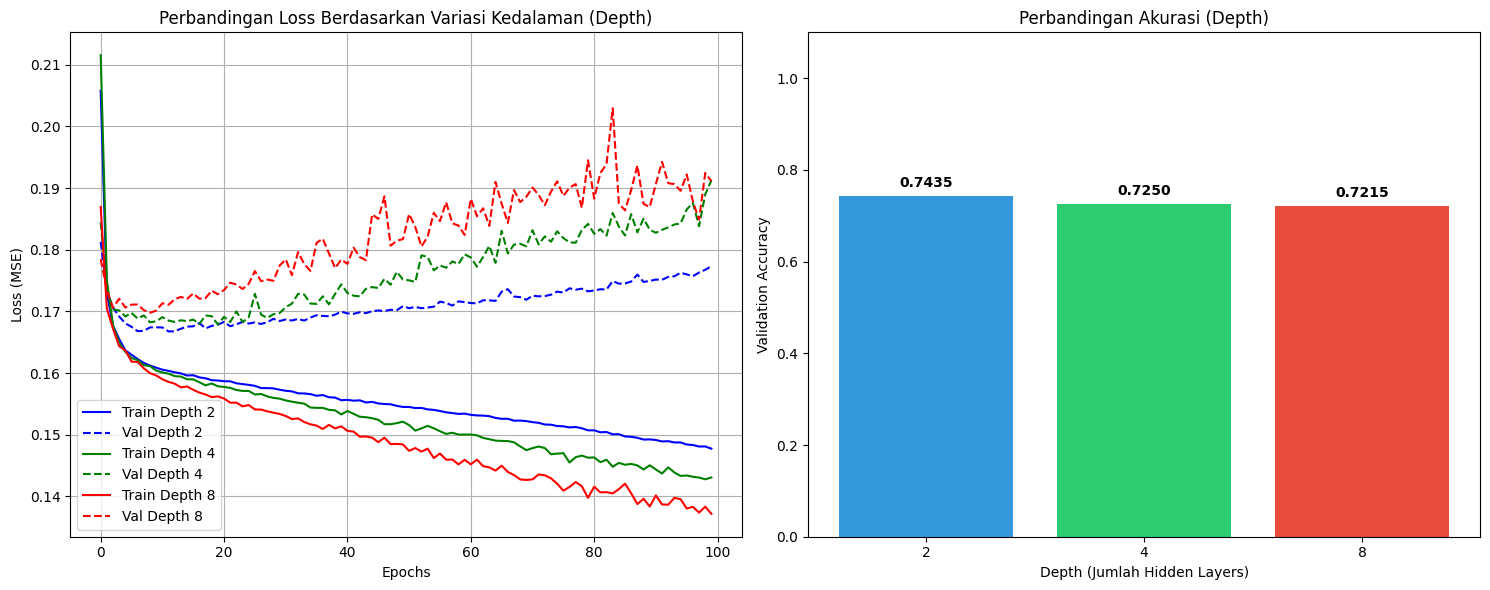

In [22]:
import matplotlib.pyplot as plt

depths = [2, 4, 8]
depth_results = {}
val_accuracies = []
input_dim = X_train_np.shape[1]

for d in depths:
    print(f"\nTraining model dengan Depth: {d} Hidden Layers")
    
    model = NeuralNetwork()
    

    model.add(DenseLayer(input_dim, 16, he_init))
    model.add(ActivationLayer(relu, relu_prime))
    
    for _ in range(d - 1):
        model.add(DenseLayer(16, 16, he_init))
        model.add(ActivationLayer(relu, relu_prime))
    
    # Output Layer
    model.add(DenseLayer(16, 1, xavier_init))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))

    model.use(mse, mse_prime)

    depth_results[d] = model.train(
        X_train_np, y_train_np,
        X_val_np, y_val_np,
        epochs=100,
        batch_size=32,
        learning_rate=0.1,
        verbose=0
    )

    y_pred = model.predict(X_val_np)
    y_pred_binary = (np.array(y_pred).flatten() >= 0.5).astype(int)
    acc = accuracy_score(y_val_np, y_pred_binary)
    val_accuracies.append(acc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ['blue', 'green', 'red']

for i, d in enumerate(depths):
    ax1.plot(depth_results[d]['train_loss'], color=colors[i], label=f'Train Depth {d}')
    ax1.plot(depth_results[d]['val_loss'], '--', color=colors[i], label=f'Val Depth {d}')

ax1.set_title('Perbandingan Loss Berdasarkan Variasi Kedalaman (Depth)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)')
ax1.legend()
ax1.grid(True)

ax2.set_title('Perbandingan Akurasi (Depth)')
ax2.set_xlabel('Depth (Jumlah Hidden Layers)')
ax2.set_ylabel('Validation Accuracy')
ax2.set_ylim(0, 1.1)
bars = ax2.bar([str(d) for d in depths], val_accuracies, color=['#3498db', '#2ecc71', '#e74c3c'])
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', fontweight='bold')

plt.tight_layout()

plt.show()

### Pengujian 1.2. Activation Function

Training selesai.

Epoch 1/20 | Train Loss: 1.378212 | Val Loss: 1.319843
Epoch 2/20 | Train Loss: 1.295313 | Val Loss: 1.284826
Epoch 3/20 | Train Loss: 1.273898 | Val Loss: 1.272579
Epoch 4/20 | Train Loss: 1.263699 | Val Loss: 1.266290
Epoch 5/20 | Train Loss: 1.256796 | Val Loss: 1.261570
Epoch 6/20 | Train Loss: 1.251423 | Val Loss: 1.257561
Epoch 7/20 | Train Loss: 1.246795 | Val Loss: 1.254311
Epoch 8/20 | Train Loss: 1.242710 | Val Loss: 1.251266
Epoch 9/20 | Train Loss: 1.239142 | Val Loss: 1.248588
Epoch 10/20 | Train Loss: 1.235646 | Val Loss: 1.246593
Epoch 11/20 | Train Loss: 1.232907 | Val Loss: 1.244034
Epoch 12/20 | Train Loss: 1.230233 | Val Loss: 1.241928
Epoch 13/20 | Train Loss: 1.227640 | Val Loss: 1.239882
Epoch 14/20 | Train Loss: 1.225044 | Val Loss: 1.238424
Epoch 15/20 | Train Loss: 1.222967 | Val Loss: 1.236364
Epoch 16/20 | Train Loss: 1.220712 | Val Loss: 1.234903
Epoch 17/20 | Train Loss: 1.218606 | Val Loss: 1.233395
Epoch 18/20 | Train Loss: 1.216746 | V

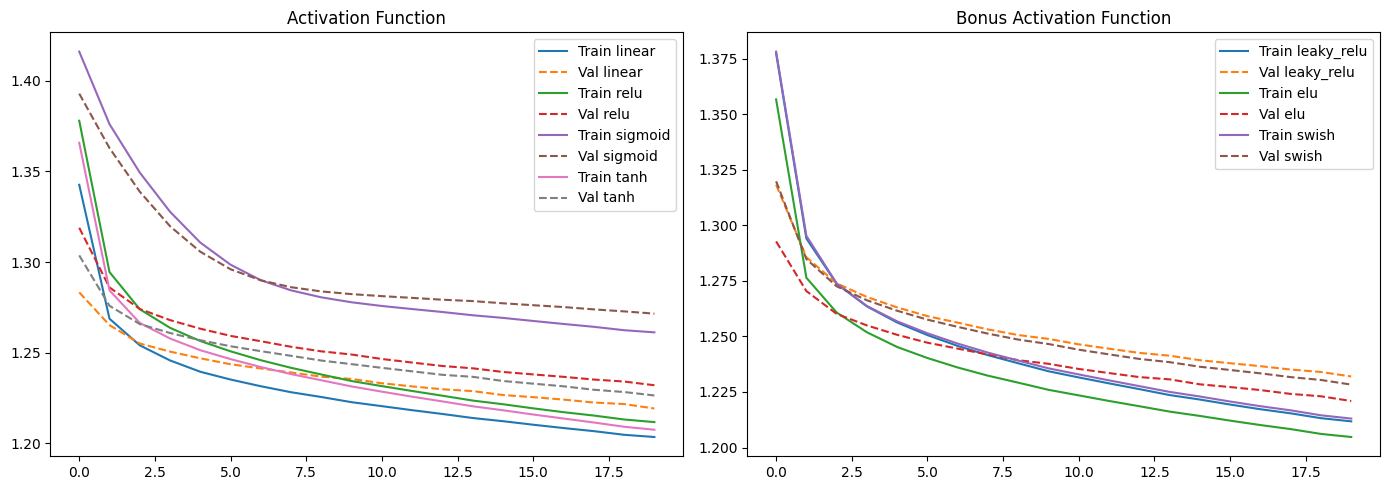

In [41]:
activation = {
    "linear": (linear, linear_prime),
    "relu": (relu, relu_prime),
    "sigmoid": (sigmoid, sigmoid_prime),
    "tanh": (hyperbolic_tangent, hyperbolic_tangent_prime),
}

bonus_activation = {
    "leaky_relu": (leaky_relu, leaky_relu_prime),
    "elu": (elu, elu_prime),
    "swish": (swish, swish_prime)
}

input_dim = X_train_np.shape[1]

def build_train_model(activation_lib, ax, plot_title):
    for i, act in enumerate(activation_lib):
        print(f"Testing activation function: {act}")
        model = NeuralNetwork()
        model.add(DenseLayer(input_dim, 32, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
        model.add(ActivationLayer(relu, relu_prime))
        model.add(DenseLayer(32, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
        model.add(ActivationLayer(*activation_lib[act]))
        model.add(DenseLayer(16, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
        model.add(ActivationLayer(sigmoid, sigmoid_prime))

        model.use(bce, bce_prime)

        history = model.train(
            X_train_np, y_train_np,
            X_val_np, y_val_np,
            epochs=20,
            batch_size=32,
            learning_rate=0.01,
            verbose=1
        )
        ax.plot(history['train_loss'], linestyle='-', label=f'Train {act}')
        ax.plot(history['val_loss'], linestyle='--', label=f'Val {act}')
    ax.set_title(plot_title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
build_train_model(activation, axes[0], "Activation Function")
build_train_model(bonus_activation, axes[1], "Bonus Activation Function")
plt.tight_layout()
plt.show()

### Pengujian 1.3. Learning Rate

Training selesai.

Epoch 1/20 | Train Loss: 1.449343 | Val Loss: 1.426320
Epoch 2/20 | Train Loss: 1.408823 | Val Loss: 1.400421
Epoch 3/20 | Train Loss: 1.383224 | Val Loss: 1.375685
Epoch 4/20 | Train Loss: 1.360792 | Val Loss: 1.356538
Epoch 5/20 | Train Loss: 1.339315 | Val Loss: 1.337026
Epoch 6/20 | Train Loss: 1.319174 | Val Loss: 1.317840
Epoch 7/20 | Train Loss: 1.300331 | Val Loss: 1.297996
Epoch 8/20 | Train Loss: 1.281329 | Val Loss: 1.279603
Epoch 9/20 | Train Loss: 1.263384 | Val Loss: 1.262575
Epoch 10/20 | Train Loss: 1.245347 | Val Loss: 1.246149
Epoch 11/20 | Train Loss: 1.228515 | Val Loss: 1.228283
Epoch 12/20 | Train Loss: 1.211635 | Val Loss: 1.212475
Epoch 13/20 | Train Loss: 1.195533 | Val Loss: 1.198097
Epoch 14/20 | Train Loss: 1.179416 | Val Loss: 1.182822
Epoch 15/20 | Train Loss: 1.164471 | Val Loss: 1.166898
Epoch 16/20 | Train Loss: 1.149033 | Val Loss: 1.153295
Epoch 17/20 | Train Loss: 1.134851 | Val Loss: 1.137825
Epoch 18/20 | Train Loss: 1.119902 | V

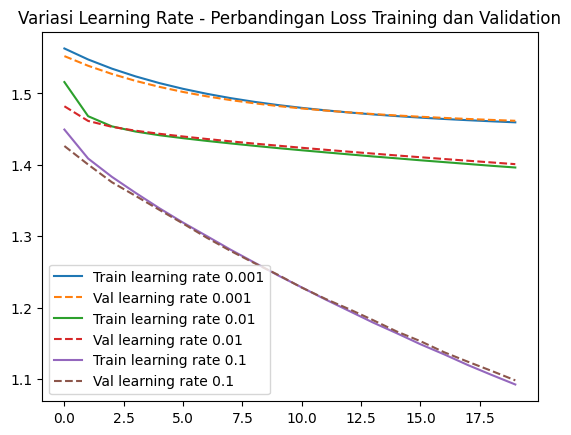

In [ ]:
learning_rate = {
    "learning rate 0.001": 0.001,
    "learning rate 0.01": 0.01,
    "learning rate 0.1": 0.1
}

input_dim = X_train_np.shape[1]

for i, lr in enumerate(learning_rate):
    print(f"Testing learning rate: {lr}")
    model = NeuralNetwork()
    model.add(DenseLayer(input_dim, 64, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    model.add(DenseLayer(64, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    model.add(DenseLayer(16, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))

    model.use(mse, mse_prime)

    history = model.train(
        X_train_np, y_train_np,
        X_val_np, y_val_np,
        epochs=20,
        batch_size=32,
        learning_rate=learning_rate[lr],
        verbose=1
    )
    print()
    plt.plot(history['train_loss'], linestyle='-', label=f'Train {lr}')
    plt.plot(history['val_loss'], linestyle='--', label=f'Val {lr}')

plt.title(f"Variasi Learning Rate - Perbandingan Loss Training dan Validation")
plt.legend()
plt.show()

### Test Regularization

In [25]:
# init
bce = loss_fn.binary_cross_entropy
bce_prime = loss_fn.bce_prime

# helper build model
def build_regularization_model(l1_lambda=0.0, l2_lambda=0.0, seed=42):
    model = NeuralNetwork()
    input_size = X_train_np.shape[1]

    model.add(DenseLayer(input_size, 16, he_init, l1_lambda=l1_lambda, l2_lambda=l2_lambda, seed=seed))
    model.add(ActivationLayer(relu, relu_prime))

    model.add(DenseLayer(16, 8, xavier_init, l1_lambda=l1_lambda, l2_lambda=l2_lambda, seed=seed))
    model.add(ActivationLayer(relu, relu_prime))

    model.add(DenseLayer(8, 1, xavier_init, l1_lambda=l1_lambda, l2_lambda=l2_lambda, seed=seed))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))

    model.use(bce, bce_prime)
    return model

# helper evaluasi prediksi
def evaluate_binary_model(model, X_val, y_val, model_name="Model", threshold=0.5):
    y_prob = model.predict(X_val)
    y_pred = (y_prob >= threshold).astype(int).reshape(-1)
    y_true = y_val.reshape(-1)

    print()
    print(model_name)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Not Placed", "Placed"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()
    accuracy = report_df.loc["accuracy", "precision"]
    report_df = report_df.drop("accuracy")
    display(report_df)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Accuracy  : {acc:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")
    print()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [26]:
# init hyperparameter untuk regularization
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.01
REG_LAMBDA = 0.001
SEED = 42

#### a. Tanpa regularisasi

In [27]:
model_none = build_regularization_model(l1_lambda=0.0, l2_lambda=0.0, seed=SEED)

history_none = model_none.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

result_none = evaluate_binary_model(model_none, X_val_np, y_val_np, "No Regularization")

Training selesai.

Epoch 1/50 | Train Loss: 0.638894 | Val Loss: 0.593688
Epoch 2/50 | Train Loss: 0.566494 | Val Loss: 0.548910
Epoch 3/50 | Train Loss: 0.533209 | Val Loss: 0.528526
Epoch 4/50 | Train Loss: 0.518014 | Val Loss: 0.521634
Epoch 5/50 | Train Loss: 0.510252 | Val Loss: 0.517837
Epoch 6/50 | Train Loss: 0.505714 | Val Loss: 0.515919
Epoch 7/50 | Train Loss: 0.502634 | Val Loss: 0.515156
Epoch 8/50 | Train Loss: 0.500187 | Val Loss: 0.513700
Epoch 9/50 | Train Loss: 0.498300 | Val Loss: 0.512365
Epoch 10/50 | Train Loss: 0.496583 | Val Loss: 0.511931
Epoch 11/50 | Train Loss: 0.495406 | Val Loss: 0.511345
Epoch 12/50 | Train Loss: 0.494250 | Val Loss: 0.511143
Epoch 13/50 | Train Loss: 0.493334 | Val Loss: 0.510790
Epoch 14/50 | Train Loss: 0.492491 | Val Loss: 0.510811
Epoch 15/50 | Train Loss: 0.491885 | Val Loss: 0.510140
Epoch 16/50 | Train Loss: 0.491314 | Val Loss: 0.510128
Epoch 17/50 | Train Loss: 0.490779 | Val Loss: 0.510310
Epoch 18/50 | Train Loss: 0.490183 | V

,precision,recall,f1-score,support
Not Placed,0.702096,0.609883,0.652749,769.0
Placed,0.774775,0.838343,0.805306,1231.0
macro avg,0.738435,0.724113,0.729028,2000.0
weighted avg,0.746830,0.750500,0.746648,2000.0


Accuracy  : 0.7505
Macro F1  : 0.7290



#### b. L1 Regularization

In [28]:
model_l1 = build_regularization_model(l1_lambda=REG_LAMBDA, l2_lambda=0.0, seed=SEED)

history_l1 = model_l1.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

result_l1 = evaluate_binary_model(model_l1, X_val_np, y_val_np, "L1 Regularization")

Training selesai.

Epoch 1/50 | Train Loss: 0.757413 | Val Loss: 0.712489
Epoch 2/50 | Train Loss: 0.685638 | Val Loss: 0.668317
Epoch 3/50 | Train Loss: 0.652855 | Val Loss: 0.648278
Epoch 4/50 | Train Loss: 0.637839 | Val Loss: 0.641481
Epoch 5/50 | Train Loss: 0.630092 | Val Loss: 0.637632
Epoch 6/50 | Train Loss: 0.625498 | Val Loss: 0.635631
Epoch 7/50 | Train Loss: 0.622308 | Val Loss: 0.634709
Epoch 8/50 | Train Loss: 0.619728 | Val Loss: 0.633105
Epoch 9/50 | Train Loss: 0.617711 | Val Loss: 0.631691
Epoch 10/50 | Train Loss: 0.615856 | Val Loss: 0.631172
Epoch 11/50 | Train Loss: 0.614614 | Val Loss: 0.630447
Epoch 12/50 | Train Loss: 0.613356 | Val Loss: 0.630185
Epoch 13/50 | Train Loss: 0.612364 | Val Loss: 0.629706
Epoch 14/50 | Train Loss: 0.611416 | Val Loss: 0.629648
Epoch 15/50 | Train Loss: 0.610744 | Val Loss: 0.628897
Epoch 16/50 | Train Loss: 0.610054 | Val Loss: 0.628778
Epoch 17/50 | Train Loss: 0.609481 | Val Loss: 0.628879
Epoch 18/50 | Train Loss: 0.608764 | V

,precision,recall,f1-score,support
Not Placed,0.703148,0.609883,0.653203,769.0
Placed,0.774944,0.839155,0.805772,1231.0
macro avg,0.739046,0.724519,0.729488,2000.0
weighted avg,0.747338,0.751000,0.747109,2000.0


Accuracy  : 0.7510
Macro F1  : 0.7295



#### c. L2 Regularization

In [29]:
model_l2 = build_regularization_model(l1_lambda=0.0, l2_lambda=REG_LAMBDA, seed=SEED)

history_l2 = model_l2.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

result_l2 = evaluate_binary_model(model_l2, X_val_np, y_val_np, "L2 Regularization")

Training selesai.

Epoch 1/50 | Train Loss: 0.659939 | Val Loss: 0.614828
Epoch 2/50 | Train Loss: 0.587782 | Val Loss: 0.570329
Epoch 3/50 | Train Loss: 0.554746 | Val Loss: 0.550133
Epoch 4/50 | Train Loss: 0.539671 | Val Loss: 0.543330
Epoch 5/50 | Train Loss: 0.531969 | Val Loss: 0.539565
Epoch 6/50 | Train Loss: 0.527434 | Val Loss: 0.537632
Epoch 7/50 | Train Loss: 0.524356 | Val Loss: 0.536857
Epoch 8/50 | Train Loss: 0.521889 | Val Loss: 0.535370
Epoch 9/50 | Train Loss: 0.519976 | Val Loss: 0.534010
Epoch 10/50 | Train Loss: 0.518224 | Val Loss: 0.533570
Epoch 11/50 | Train Loss: 0.517040 | Val Loss: 0.532950
Epoch 12/50 | Train Loss: 0.515859 | Val Loss: 0.532746
Epoch 13/50 | Train Loss: 0.514930 | Val Loss: 0.532366
Epoch 14/50 | Train Loss: 0.514066 | Val Loss: 0.532375
Epoch 15/50 | Train Loss: 0.513446 | Val Loss: 0.531678
Epoch 16/50 | Train Loss: 0.512854 | Val Loss: 0.531663
Epoch 17/50 | Train Loss: 0.512317 | Val Loss: 0.531817
Epoch 18/50 | Train Loss: 0.511702 | V

,precision,recall,f1-score,support
Not Placed,0.702096,0.609883,0.652749,769.0
Placed,0.774775,0.838343,0.805306,1231.0
macro avg,0.738435,0.724113,0.729028,2000.0
weighted avg,0.746830,0.750500,0.746648,2000.0


Accuracy  : 0.7505
Macro F1  : 0.7290



#### Perbandingan Regularisasi

In [30]:
# tabel perbandingan
comparison_df = pd.DataFrame([
    {
        "Model": "No Regularization",
        "Accuracy": result_none["accuracy"],
        "Macro F1": result_none["macro_f1"]
    },
    {
        "Model": "L1 Regularization",
        "Accuracy": result_l1["accuracy"],
        "Macro F1": result_l1["macro_f1"]
    },
    {
        "Model": "L2 Regularization",
        "Accuracy": result_l2["accuracy"],
        "Macro F1": result_l2["macro_f1"]
    }
])

comparison_df.sort_values(by="Macro F1", ascending=False)

,Model,Accuracy,Macro F1
1,L1 Regularization,0.7510,0.729488
0,No Regularization,0.7505,0.729028
2,L2 Regularization,0.7505,0.729028


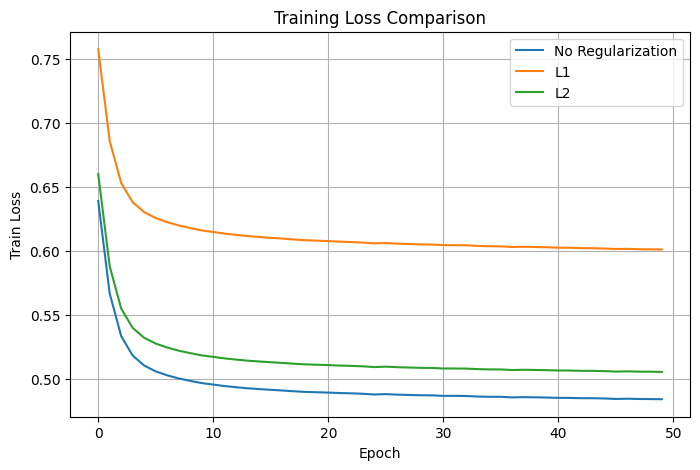

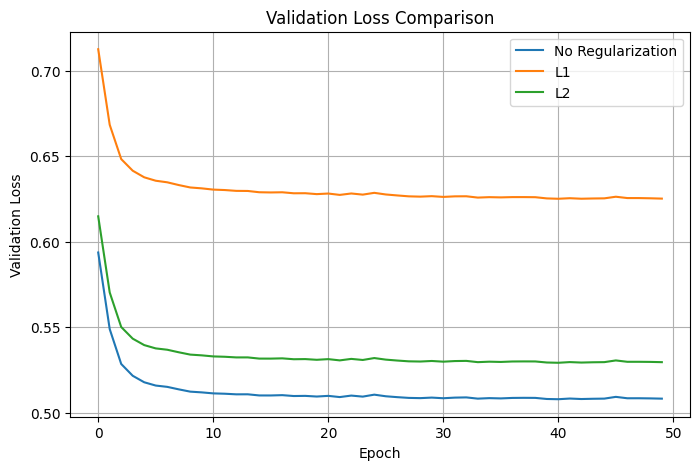


Weight Distribution - No Regularization


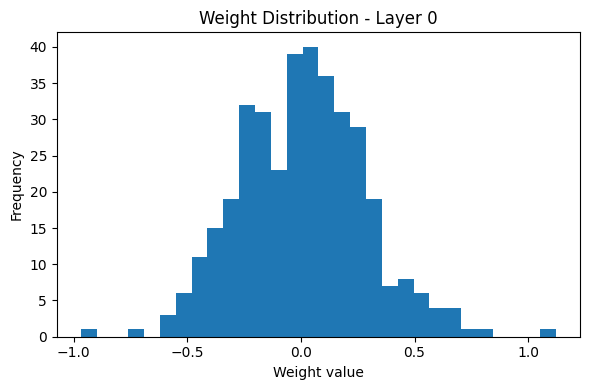

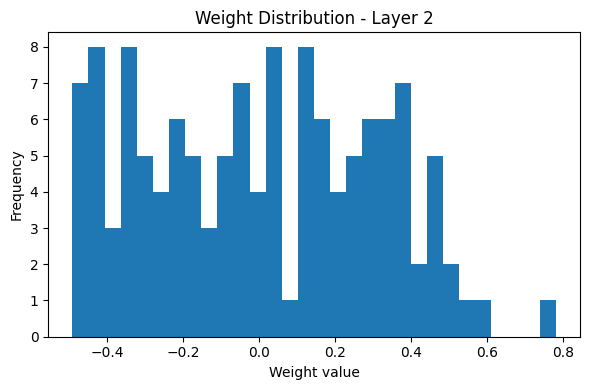

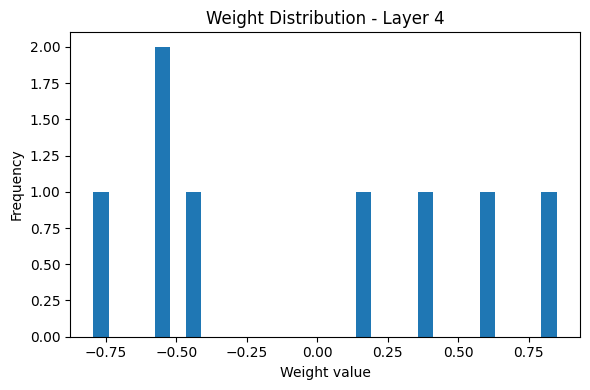

Weight Distribution - L1 Regularization


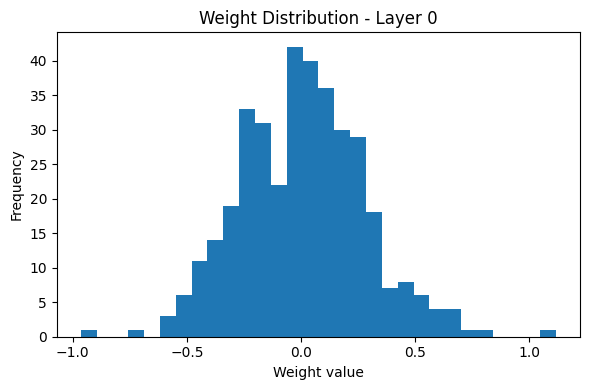

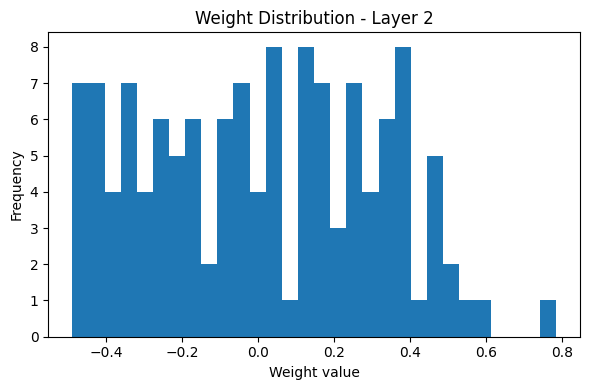

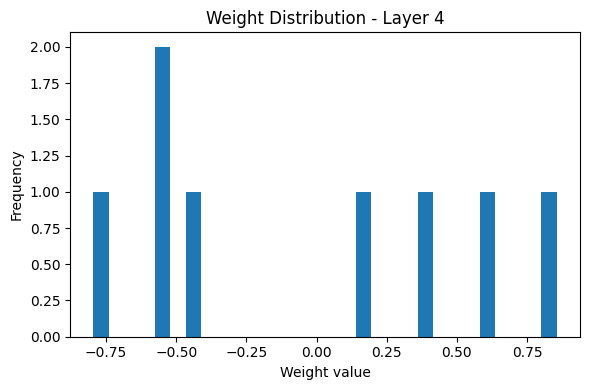

Weight Distribution - L2 Regularization


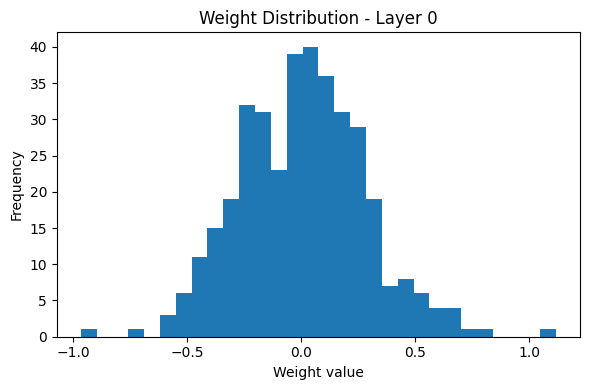

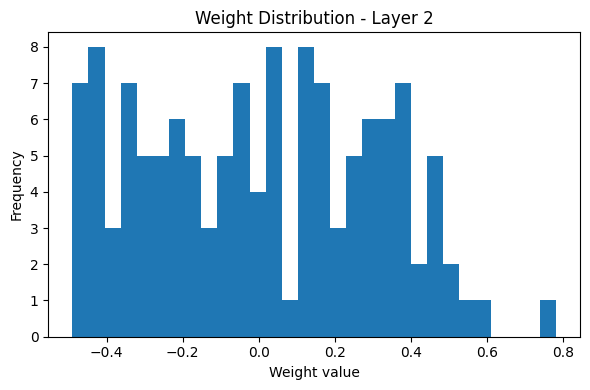

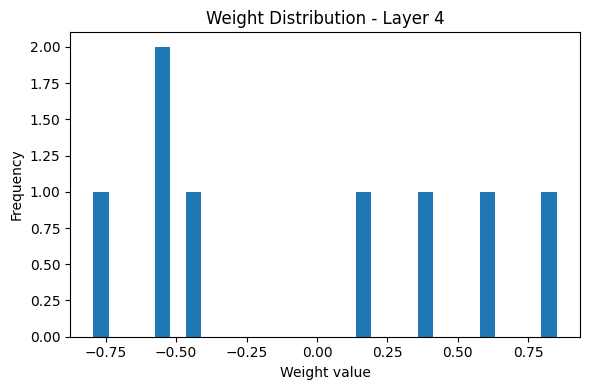


Gradient Distribution - No Regularization


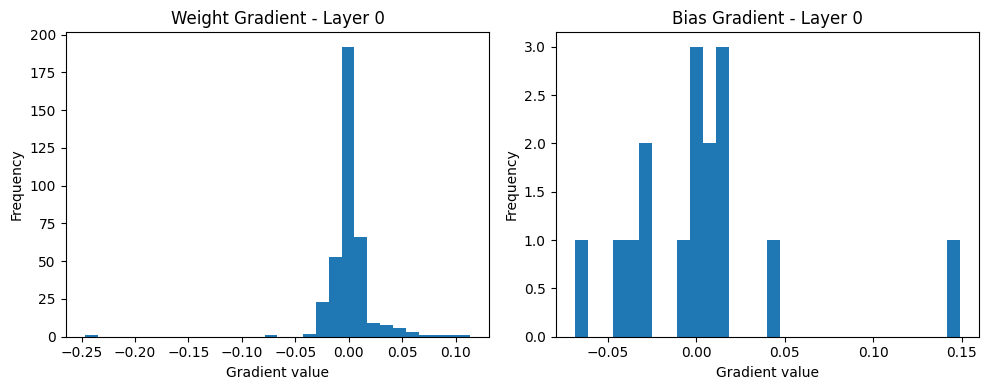

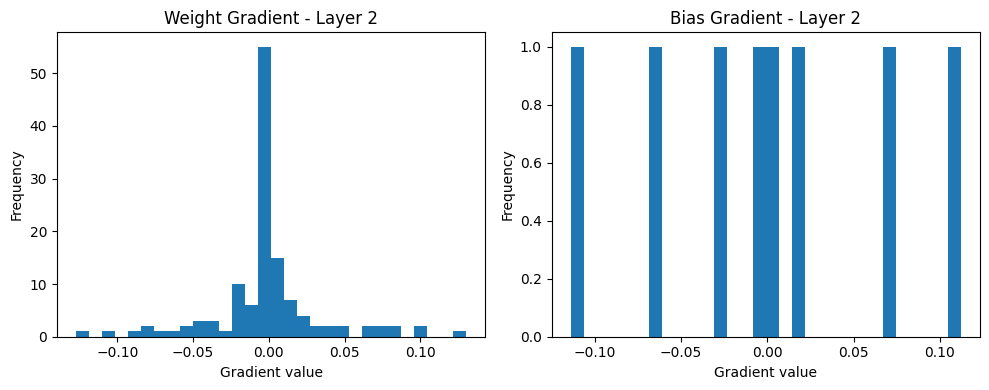

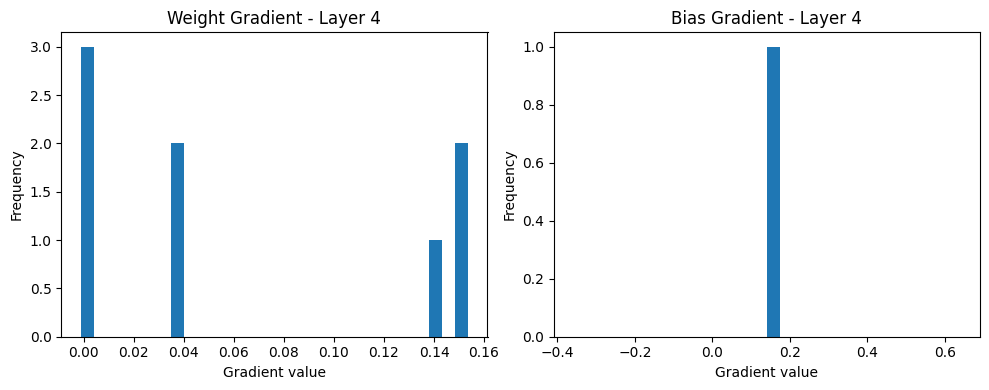

Gradient Distribution - L1 Regularization


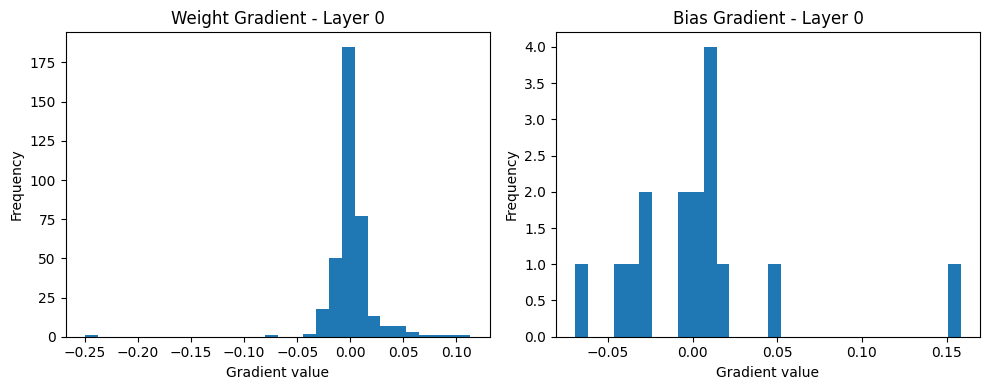

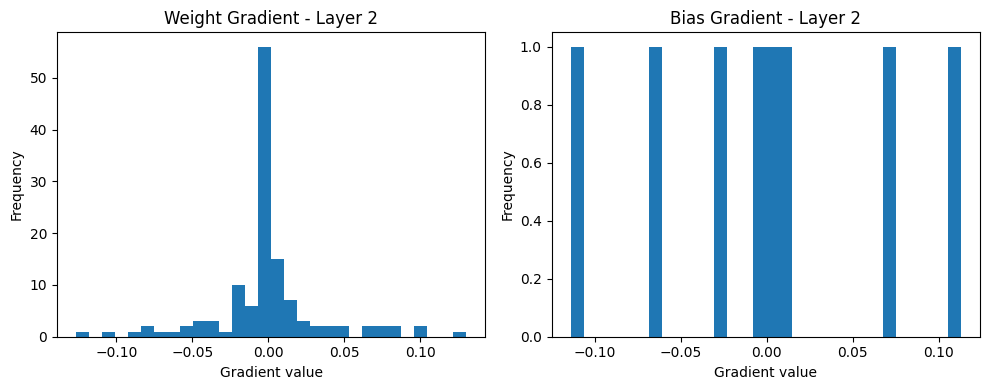

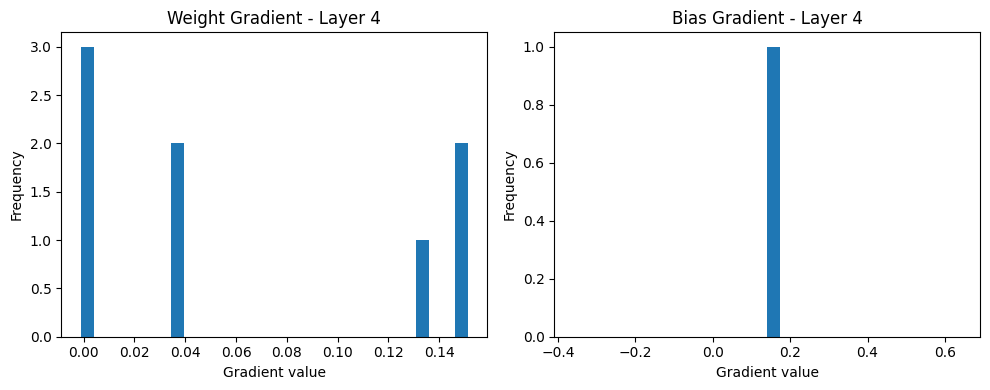

Gradient Distribution - L2 Regularization


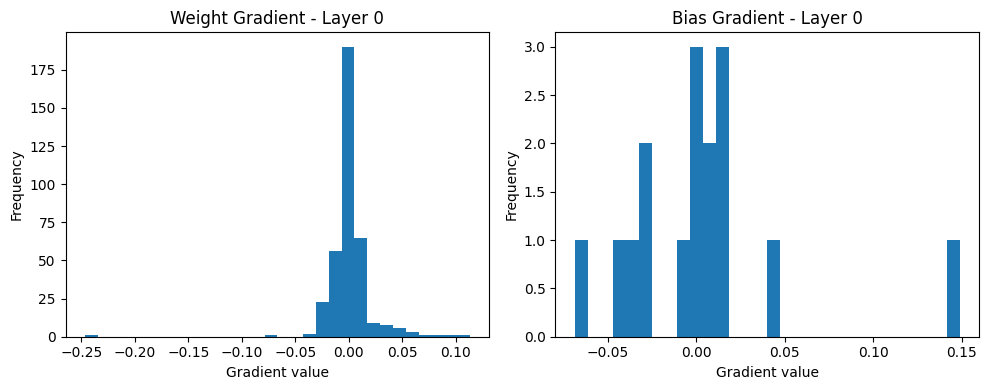

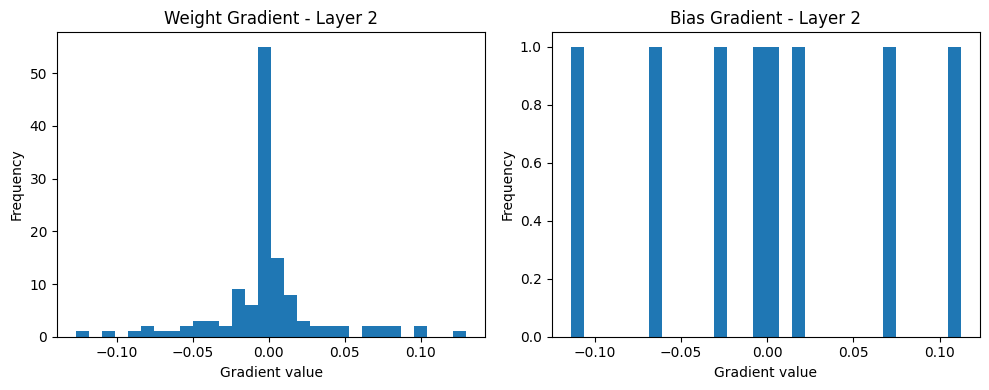

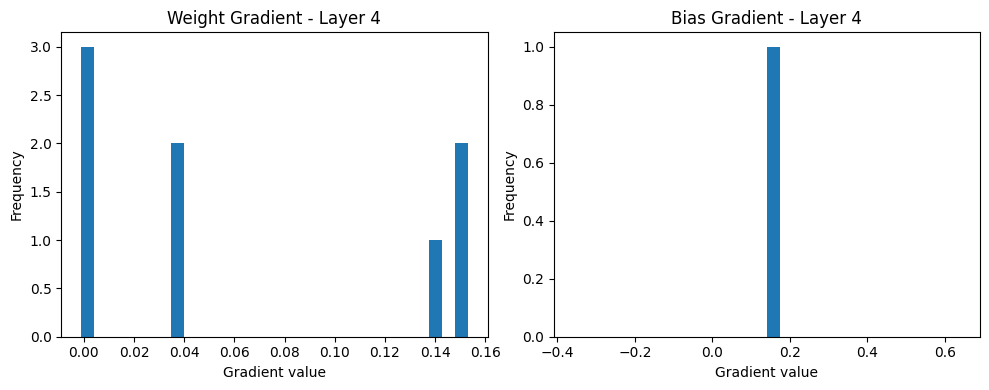

In [31]:
# plot training loss
plt.figure(figsize=(8, 5))
plt.plot(history_none["train_loss"], label="No Regularization")
plt.plot(history_l1["train_loss"], label="L1")
plt.plot(history_l2["train_loss"], label="L2")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

# plot validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_none["val_loss"], label="No Regularization")
plt.plot(history_l1["val_loss"], label="L1")
plt.plot(history_l2["val_loss"], label="L2")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

# plot distribusi weight
print("\nWeight Distribution - No Regularization")
model_none.plot_weight_distribution([0, 2, 4])

print("Weight Distribution - L1 Regularization")
model_l1.plot_weight_distribution([0, 2, 4])

print("Weight Distribution - L2 Regularization")
model_l2.plot_weight_distribution([0, 2, 4])

# plot distribusi gradient
print("\nGradient Distribution - No Regularization")
model_none.plot_gradient_distribution([0, 2, 4])

print("Gradient Distribution - L1 Regularization")
model_l1.plot_gradient_distribution([0, 2, 4])

print("Gradient Distribution - L2 Regularization")
model_l2.plot_gradient_distribution([0, 2, 4])

#### Uji Perbandingan dengan Sklearn

In [32]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [33]:
# init hyperparameter
SEED = 42
EPOCHS = 300
LEARNING_RATE = 0.01
BATCH_SIZE = 32

In [34]:
custom_model = build_regularization_model(l1_lambda=0.0, l2_lambda=0.0, seed=SEED)
custom_model.use(bce, bce_prime)

history_custom = custom_model.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

custom_result = evaluate_binary_model(
    custom_model,
    X_val_np,
    y_val_np,
    model_name="Custom FFNN"
)

# train model sklearn
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="sgd",
    learning_rate="constant",
    learning_rate_init=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    max_iter=EPOCHS,
    shuffle=True,
    random_state=SEED,
    alpha=0.0,
    momentum=0.0,
    nesterovs_momentum=False,
    early_stopping=False,
    tol=0.0
)

sklearn_model.fit(X_train_np, y_train_np.reshape(-1))

def evaluate_sklearn_model(model, X_val, y_val, model_name="Sklearn MLP"):
    y_pred = model.predict(X_val)
    y_true = y_val.reshape(-1)

    print()
    print(model_name)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Not Placed", "Placed"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()
    report_df = report_df.drop("accuracy")
    display(report_df)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Accuracy  : {acc:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")
    print()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred
    }

sklearn_result = evaluate_sklearn_model(
    sklearn_model,
    X_val_np,
    y_val_np,
    model_name="Sklearn MLPClassifier"
)

Training selesai.

Epoch 1/300 | Train Loss: 0.638894 | Val Loss: 0.593688
Epoch 2/300 | Train Loss: 0.566494 | Val Loss: 0.548910
Epoch 3/300 | Train Loss: 0.533209 | Val Loss: 0.528526
Epoch 4/300 | Train Loss: 0.518014 | Val Loss: 0.521634
Epoch 5/300 | Train Loss: 0.510252 | Val Loss: 0.517837
Epoch 6/300 | Train Loss: 0.505714 | Val Loss: 0.515919
Epoch 7/300 | Train Loss: 0.502634 | Val Loss: 0.515156
Epoch 8/300 | Train Loss: 0.500187 | Val Loss: 0.513700
Epoch 9/300 | Train Loss: 0.498300 | Val Loss: 0.512365
Epoch 10/300 | Train Loss: 0.496583 | Val Loss: 0.511931
Epoch 11/300 | Train Loss: 0.495406 | Val Loss: 0.511345
Epoch 12/300 | Train Loss: 0.494250 | Val Loss: 0.511143
Epoch 13/300 | Train Loss: 0.493334 | Val Loss: 0.510790
Epoch 14/300 | Train Loss: 0.492491 | Val Loss: 0.510811
Epoch 15/300 | Train Loss: 0.491885 | Val Loss: 0.510140
Epoch 16/300 | Train Loss: 0.491314 | Val Loss: 0.510128
Epoch 17/300 | Train Loss: 0.490779 | Val Loss: 0.510310
Epoch 18/300 | Train 

,precision,recall,f1-score,support
Not Placed,0.698551,0.626788,0.660727,769.0
Placed,0.780916,0.831032,0.805195,1231.0
macro avg,0.739733,0.728910,0.732961,2000.0
weighted avg,0.749247,0.752500,0.749647,2000.0


Accuracy  : 0.7525
Macro F1  : 0.7330


Sklearn MLPClassifier


C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,precision,recall,f1-score,support
Not Placed,0.696241,0.602081,0.645746,769.0
Placed,0.770787,0.835906,0.802027,1231.0
macro avg,0.733514,0.718993,0.723886,2000.0
weighted avg,0.742124,0.746000,0.741937,2000.0


Accuracy  : 0.7460
Macro F1  : 0.7239



#### Tabel Perbandingan

In [35]:
comparison_sklearn_df = pd.DataFrame([
    {
        "Model": "Custom FFNN",
        "Accuracy": custom_result["accuracy"],
        "Macro F1": custom_result["macro_f1"]
    },
    {
        "Model": "Sklearn MLPClassifier",
        "Accuracy": sklearn_result["accuracy"],
        "Macro F1": sklearn_result["macro_f1"]
    }
])

display(comparison_sklearn_df)

,Model,Accuracy,Macro F1
0,Custom FFNN,0.7525,0.732961
1,Sklearn MLPClassifier,0.7460,0.723886
